# Orientation and Evaluation: The Cognitive Phases of Search

Search on a SERP is not a uniform process. This notebook decomposes it into measurable cognitive phases using fixation data, pupil dilation (LHIPA), and scroll behavior:

1. **Orientation** — page load to first result fixation. The user's visual system calibrates to the page layout.
2. **Serial evaluation** — scanning results top-to-bottom. Fixation count per result declines with position; per-fixation duration is flat (~220ms). The user allocates fewer looks, not shorter looks.
3. **Working memory accumulation** — as more results are evaluated, the comparison set grows. Forward-only dwell *increases* with position (ρ = +0.82). LHIPA *decreases* with click depth (ρ = -0.90). The user is working harder, not losing interest.
4. **Transition to commitment** — the evaluation loop terminates in either a click or a regression.

The standard narrative — "users spend less time on lower results because they care less" — is wrong. The decomposition shows an *attention allocation* decision (fewer fixations) masking an *increasing cognitive load* (higher dwell ratio, lower LHIPA). The user is doing more with less.

In [1]:
import os, csv, json, time
from collections import defaultdict
from bisect import bisect_right
import numpy as np
import pywt
import matplotlib.pyplot as plt
from scipy import stats
import xml.etree.ElementTree as ET

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

DATA_DIR = os.path.join('..', 'AdSERP', 'data')
PUPIL_DIR = os.path.join(DATA_DIR, 'pupil-data')
MOUSE_DIR = os.path.join(DATA_DIR, 'mouse-movement-data')
FIXATION_DIR = os.path.join(DATA_DIR, 'fixation-data')
METADATA_DIR = os.path.join(DATA_DIR, 'trial-metadata')

# Load pre-computed LHIPA
with open(os.path.join(DATA_DIR, 'trial-lhipa.json')) as f:
    trial_lhipa = json.load(f)

print(f'Trials with LHIPA: {len(trial_lhipa)}')

# LHIPA function for per-segment computation
def compute_lhipa(pupil_signal, wavelet='sym16'):
    signal = np.array(pupil_signal, dtype=float)
    n = len(signal)
    if n < 64:
        return None
    w = pywt.Wavelet(wavelet)
    max_level = pywt.dwt_max_level(n, w.dec_len)
    if max_level < 2:
        return None
    hif = 1
    lof = max(max_level // 2, 2)
    if lof <= hif:
        lof = hif + 1
    if lof > max_level:
        return None
    cD_H = pywt.downcoef('d', signal, wavelet, mode='per', level=hif) / np.sqrt(2**hif)
    cD_L = pywt.downcoef('d', signal, wavelet, mode='per', level=lof) / np.sqrt(2**lof)
    rf = max(len(cD_H) // len(cD_L), 1)
    ratio = np.zeros(len(cD_L))
    for i in range(len(cD_L)):
        s, e = i * rf, min(i * rf + rf, len(cD_H))
        hm = np.mean(np.abs(cD_H[s:e]))
        if hm > 1e-10:
            ratio[i] = np.abs(cD_L[i]) / hm
    if len(ratio) < 3:
        return None
    ar = np.abs(ratio)
    maxima = np.array([ar[i] for i in range(1, len(ar)-1) if ar[i] > ar[i-1] and ar[i] > ar[i+1]])
    if len(maxima) == 0:
        return 0.0
    sigma = np.median(np.abs(cD_H)) / 0.6745
    threshold = sigma * np.sqrt(2 * np.log2(max(n, 2)))
    return int(np.sum(maxima > threshold)) / n

def result_bands(n, dh):
    header = 200
    per = (dh - 400) / max(n, 1)
    return [(header + i * per, header + (i+1) * per) for i in range(n)]

Trials with LHIPA: 2721


In [2]:
# ── Load per-trial data: fixations, scroll, pupil, metadata ──────────

print('Loading trial data...')
trials = {}  # tid → full trial record

trial_ids = sorted([f.replace('.csv','') for f in os.listdir(FIXATION_DIR) if f.endswith('.csv')])

for tid in trial_ids:
    # Metadata
    try:
        tree = ET.parse(os.path.join(METADATA_DIR, f'{tid}.xml'))
        doc_h = int(tree.find('.//document').text.split('x')[1])
        scr_h = int(tree.find('.//screen').text.split('x')[1])
    except:
        continue
    
    # Fixations
    fixations = []
    with open(os.path.join(FIXATION_DIR, f'{tid}.csv')) as f:
        for row in csv.DictReader(f):
            try:
                fixations.append({
                    't': int(float(row['timestamp'])),
                    'x': float(row['FPOGX']),
                    'y': float(row['FPOGY']),
                    'd': float(row['FPOGD']),
                })
            except:
                continue
    if not fixations:
        continue
    
    # Mouse/scroll events
    mouse_path = os.path.join(MOUSE_DIR, f'{tid}.csv')
    if not os.path.exists(mouse_path):
        continue
    scrolls = []
    click_t = None
    click_y = None
    all_ts = []
    first_mousemove = None
    first_scroll = None
    with open(mouse_path) as f:
        for row in csv.DictReader(f):
            t = int(float(row['timestamp']))
            all_ts.append(t)
            if row['event'] == 'scroll':
                scrolls.append((t, float(row['ypos'])))
                if first_scroll is None:
                    first_scroll = t
            if row['event'] == 'mousemove' and first_mousemove is None:
                first_mousemove = t
            if row['event'] == 'click' and click_t is None:
                click_t = t
                click_y = float(row['ypos'])
    
    if not all_ts or click_t is None:
        continue
    
    trial_start = min(all_ts)
    
    # Click position
    sts = [s[0] for s in scrolls]
    sys_ = [s[1] for s in scrolls]
    so_click = 0.0
    if sts:
        if click_t <= sts[0]: so_click = sys_[0]
        elif click_t >= sts[-1]: so_click = sys_[-1]
        else: so_click = sys_[bisect_right(sts, click_t) - 1]
    
    bands = result_bands(10, doc_h)
    tops = [b[0] for b in bands]
    clicked_pos = bisect_right(tops, min(click_y, scr_h) + so_click) - 1
    clicked_pos = max(0, min(clicked_pos, 9))
    
    trials[tid] = {
        'doc_h': doc_h, 'scr_h': scr_h,
        'fixations': fixations,
        'scrolls': scrolls, 'sts': sts, 'sys': sys_,
        'click_t': click_t, 'click_y': click_y,
        'clicked_pos': clicked_pos,
        'trial_start': trial_start,
        'first_mousemove': first_mousemove,
        'first_scroll': first_scroll,
        'bands': bands, 'tops': tops,
        'lhipa': trial_lhipa.get(tid, {}).get('lhipa'),
    }

print(f'Loaded {len(trials)} trials')

Loading trial data...


Loaded 2774 trials


## Phase 1: Orientation

The interval from page load to first fixation on a SERP result. The user's visual system is calibrating: where are the results? Where does content begin? Is this a standard SERP layout or something unusual?

Metrics:
- **Orientation time**: page load → first fixation on any result (scroll-corrected)
- **TTI (Time to Interaction)**: page load → first mouse move or scroll
- **Pupil during orientation**: baseline pupil before evaluation begins

In [3]:
# ── Orientation phase analysis ────────────────────────────────────────

orientation_data = []  # per-trial orientation metrics

for tid, t in trials.items():
    bands = t['bands']
    scr_h = t['scr_h']
    
    # First fixation on any result (in result bands, scroll-corrected)
    first_result_fix_t = None
    first_result_pos = None
    
    for fix in t['fixations']:
        fy = max(0.0, min(fix['y'], scr_h))  # clamp
        # Scroll offset at fixation time
        so = 0.0
        if t['sts']:
            if fix['t'] <= t['sts'][0]: so = t['sys'][0]
            elif fix['t'] >= t['sts'][-1]: so = t['sys'][-1]
            else: so = t['sys'][bisect_right(t['sts'], fix['t']) - 1]
        
        page_y = fy + so
        pos = bisect_right(t['tops'], page_y) - 1
        if 0 <= pos < 10:
            first_result_fix_t = fix['t']
            first_result_pos = pos
            break
    
    if first_result_fix_t is None:
        continue
    
    orientation_ms = first_result_fix_t - t['trial_start']
    
    # TTI
    tti_ms = None
    if t['first_mousemove']:
        tti_ms = t['first_mousemove'] - t['trial_start']
    if t['first_scroll']:
        scroll_tti = t['first_scroll'] - t['trial_start']
        if tti_ms is None or scroll_tti < tti_ms:
            tti_ms = scroll_tti
    
    # Is this a first-viewport clicker (no scroll before click)?
    fv_clicker = t['first_scroll'] is None or t['first_scroll'] > t['click_t']
    
    # Pre-result fixation count (fixations before first result fixation)
    pre_result_fixations = sum(1 for fix in t['fixations'] if fix['t'] < first_result_fix_t)
    
    orientation_data.append({
        'trial': tid,
        'orientation_ms': orientation_ms,
        'tti_ms': tti_ms,
        'first_result_pos': first_result_pos,
        'fv_clicker': fv_clicker,
        'pre_result_fixations': pre_result_fixations,
        'clicked_pos': t['clicked_pos'],
        'lhipa': t['lhipa'],
    })

print(f'Orientation data: {len(orientation_data)} trials')

# ── Summary stats ─────────────────────────────────────────────────────
orient_ms = [d['orientation_ms'] for d in orientation_data if d['orientation_ms'] < 30000]
tti_ms_vals = [d['tti_ms'] for d in orientation_data if d['tti_ms'] is not None and d['tti_ms'] < 30000]

fv = [d for d in orientation_data if d['fv_clicker']]
scr = [d for d in orientation_data if not d['fv_clicker']]

print(f'\nOrientation time (page load → first result fixation):')
print(f'  All: median={np.median(orient_ms):.0f}ms, mean={np.mean(orient_ms):.0f}ms')
print(f'  First-viewport clickers (N={len(fv)}): median={np.median([d["orientation_ms"] for d in fv if d["orientation_ms"] < 30000]):.0f}ms')
print(f'  Scrollers (N={len(scr)}): median={np.median([d["orientation_ms"] for d in scr if d["orientation_ms"] < 30000]):.0f}ms')

print(f'\nTTI (page load → first mouse/scroll):')
print(f'  Median={np.median(tti_ms_vals):.0f}ms, mean={np.mean(tti_ms_vals):.0f}ms')

print(f'\nFirst result fixated:')
first_pos_counts = defaultdict(int)
for d in orientation_data:
    first_pos_counts[d['first_result_pos']] += 1
for p in range(10):
    if first_pos_counts[p] > 0:
        print(f'  Position {p}: {first_pos_counts[p]} ({first_pos_counts[p]/len(orientation_data)*100:.1f}%)')

print(f'\nPre-result fixations (header/chrome area):')
pre_fix = [d['pre_result_fixations'] for d in orientation_data]
print(f'  Median={np.median(pre_fix):.0f}, mean={np.mean(pre_fix):.1f}')

Orientation data: 2773 trials

Orientation time (page load → first result fixation):
  All: median=194ms, mean=464ms
  First-viewport clickers (N=512): median=194ms
  Scrollers (N=2261): median=194ms

TTI (page load → first mouse/scroll):
  Median=835ms, mean=2435ms

First result fixated:
  Position 0: 2516 (90.7%)
  Position 1: 180 (6.5%)
  Position 2: 46 (1.7%)
  Position 3: 19 (0.7%)
  Position 4: 9 (0.3%)
  Position 5: 2 (0.1%)
  Position 7: 1 (0.0%)

Pre-result fixations (header/chrome area):
  Median=1, mean=1.7


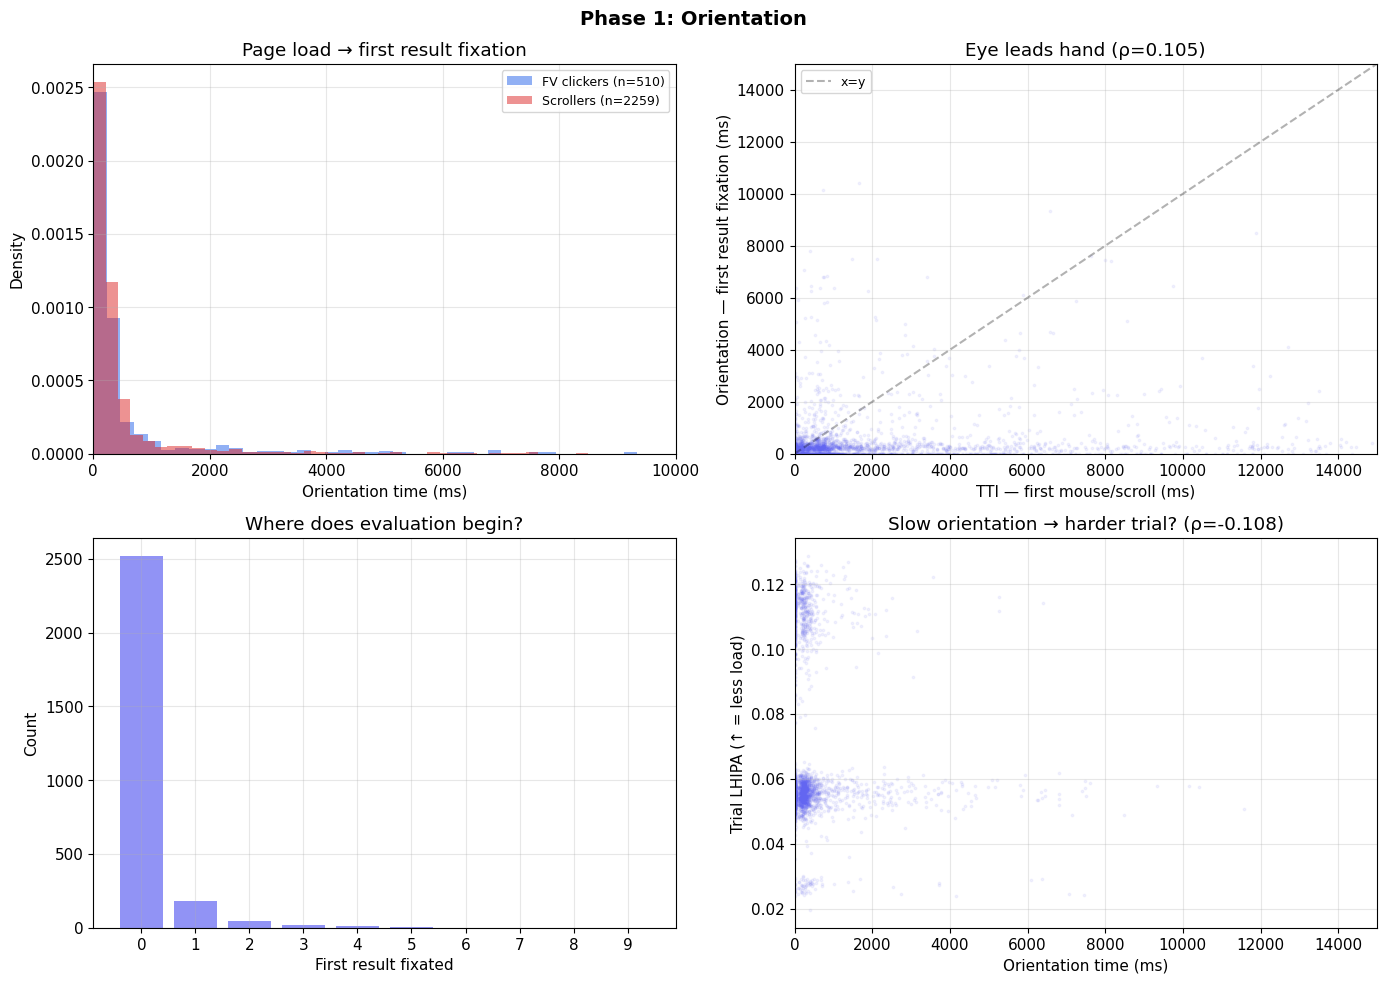

In [4]:
# ── Orientation phase plots ───────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Phase 1: Orientation', fontsize=14, fontweight='bold')

# (a) Orientation time distribution
ax = axes[0, 0]
fv_orient = [d['orientation_ms'] for d in fv if d['orientation_ms'] < 10000]
scr_orient = [d['orientation_ms'] for d in scr if d['orientation_ms'] < 10000]
ax.hist(fv_orient, bins=40, alpha=0.5, color='#2563eb', label=f'FV clickers (n={len(fv_orient)})', density=True)
ax.hist(scr_orient, bins=40, alpha=0.5, color='#dc2626', label=f'Scrollers (n={len(scr_orient)})', density=True)
ax.set_xlabel('Orientation time (ms)')
ax.set_ylabel('Density')
ax.set_title('Page load → first result fixation')
ax.legend(fontsize=9)
ax.set_xlim(0, 10000)

# (b) Orientation time vs TTI
ax = axes[0, 1]
valid = [(d['orientation_ms'], d['tti_ms']) for d in orientation_data 
         if d['tti_ms'] is not None and d['orientation_ms'] < 15000 and d['tti_ms'] < 15000]
ox, ty = zip(*valid) if valid else ([], [])
ax.scatter(ty, ox, alpha=0.08, s=3, color='#6366f1')
ax.plot([0, 15000], [0, 15000], 'k--', alpha=0.3, label='x=y')
r_ot, p_ot = stats.spearmanr(ox, ty)
ax.set_xlabel('TTI — first mouse/scroll (ms)')
ax.set_ylabel('Orientation — first result fixation (ms)')
ax.set_title(f'Eye leads hand (ρ={r_ot:.3f})')
ax.legend(fontsize=9)
ax.set_xlim(0, 15000)
ax.set_ylim(0, 15000)

# (c) First fixated position
ax = axes[1, 0]
pos_counts = [first_pos_counts.get(p, 0) for p in range(10)]
ax.bar(range(10), pos_counts, color='#6366f1', alpha=0.7)
ax.set_xlabel('First result fixated')
ax.set_ylabel('Count')
ax.set_title('Where does evaluation begin?')
ax.set_xticks(range(10))

# (d) Orientation time predicts LHIPA?
ax = axes[1, 1]
valid_lhipa = [(d['orientation_ms'], d['lhipa']) for d in orientation_data 
               if d['lhipa'] is not None and d['orientation_ms'] < 15000]
if valid_lhipa:
    ox2, lh2 = zip(*valid_lhipa)
    ax.scatter(ox2, lh2, alpha=0.08, s=3, color='#6366f1')
    r_ol, p_ol = stats.spearmanr(ox2, lh2)
    ax.set_xlabel('Orientation time (ms)')
    ax.set_ylabel('Trial LHIPA (↑ = less load)')
    ax.set_title(f'Slow orientation → harder trial? (ρ={r_ol:.3f})')
    ax.set_xlim(0, 15000)

plt.tight_layout()
plt.savefig('plot_oe1_orientation.png', dpi=200, bbox_inches='tight')
plt.show()

## Phase 2: Serial Evaluation

Once the user begins fixating results, they evaluate top-to-bottom. The key decomposition:

- **Fixation count per result** — declines with position (attention allocation decision)
- **Per-fixation duration** — flat at ~220ms (oculomotor constant)
- **Dwell ratio** — fixation time / viewport time; *increases* during forward scanning (ρ = +0.82)
- **LHIPA per result** — does cognitive load vary within the evaluation loop?

In [5]:
# ── Per-result evaluation metrics ─────────────────────────────────────

print('Computing per-result evaluation metrics...')

eval_rows = []  # One row per (trial, position)

for tid, t in trials.items():
    scr_h = t['scr_h']
    
    # Per-result: fixation count, total fixation time, individual fixation durations
    per_result = defaultdict(lambda: {'fix_count': 0, 'fix_total_ms': 0, 'fix_durations': [],
                                       'first_fix_t': None, 'first_fix_d': None})
    
    for fix in t['fixations']:
        fy = max(0.0, min(fix['y'], scr_h))
        so = 0.0
        if t['sts']:
            if fix['t'] <= t['sts'][0]: so = t['sys'][0]
            elif fix['t'] >= t['sts'][-1]: so = t['sys'][-1]
            else: so = t['sys'][bisect_right(t['sts'], fix['t']) - 1]
        
        page_y = fy + so
        pos = bisect_right(t['tops'], page_y) - 1
        if 0 <= pos < 10:
            r = per_result[pos]
            r['fix_count'] += 1
            r['fix_total_ms'] += fix['d']
            r['fix_durations'].append(fix['d'])
            if r['first_fix_t'] is None:
                r['first_fix_t'] = fix['t']
                r['first_fix_d'] = fix['d']
    
    for pos in range(10):
        r = per_result.get(pos)
        if r is None or r['fix_count'] == 0:
            continue
        
        mean_fix_d = np.mean(r['fix_durations'])
        
        eval_rows.append({
            'trial': tid,
            'position': pos,
            'fix_count': r['fix_count'],
            'fix_total_ms': r['fix_total_ms'],
            'mean_fix_duration': mean_fix_d,
            'first_fix_duration': r['first_fix_d'],
            'time_to_first_fix': (r['first_fix_t'] - t['trial_start']) / 1000,  # seconds
            'is_clicked': 1 if pos == t['clicked_pos'] else 0,
        })

print(f'Evaluation rows: {len(eval_rows)}')

# ── Position-level summaries ──────────────────────────────────────────
print(f'\n{"Pos":>4} {"Fix Count":>10} {"Fix/Fix ms":>11} {"First Fix":>10} {"TTFirst(s)":>11} {"N":>6}')
for p in range(10):
    sub = [r for r in eval_rows if r['position'] == p]
    if not sub:
        continue
    print(f'{p:>4} {np.mean([r["fix_count"] for r in sub]):>10.1f} '
          f'{np.mean([r["mean_fix_duration"] for r in sub]):>11.0f} '
          f'{np.mean([r["first_fix_duration"] for r in sub]):>10.0f} '
          f'{np.mean([r["time_to_first_fix"] for r in sub]):>11.1f} '
          f'{len(sub):>6}')

Computing per-result evaluation metrics...
Evaluation rows: 16326

 Pos  Fix Count  Fix/Fix ms  First Fix  TTFirst(s)      N
   0       19.9         206        211         0.6   2741
   1       14.2         221        218         3.8   2638
   2       10.6         225        232         7.2   2339
   3       10.0         226        234         9.5   1984
   4        9.9         228        234        11.4   1696
   5       10.9         232        236        12.8   1437
   6       10.6         227        233        15.0   1142
   7       10.0         222        233        16.5    933
   8        7.8         226        232        17.7    777
   9       12.2         223        236        19.2    639


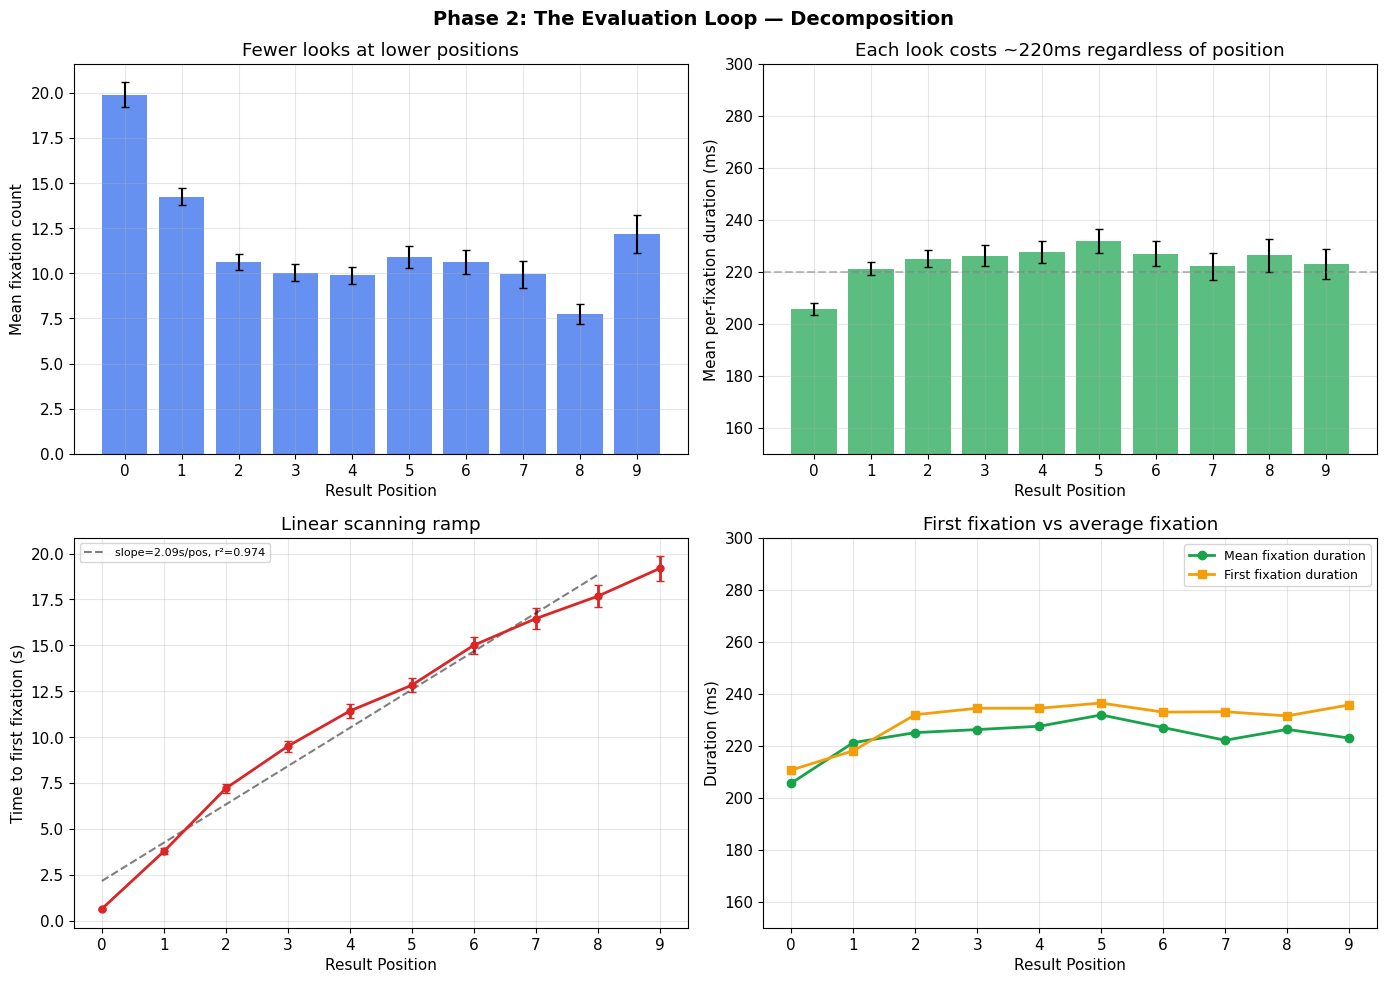


Fixation count × position: ρ = -0.4424 (p = 2.0042e-01)
Per-fixation duration × position: ρ = 0.3576 (p = 3.1038e-01)
Scanning rate: 2.09s per position (intercept = 2.16s)


In [6]:
# ── Evaluation decomposition plots ────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Phase 2: The Evaluation Loop — Decomposition', fontsize=14, fontweight='bold')

positions = list(range(10))

# (a) Fixation count per result — declining
ax = axes[0, 0]
fc_means = [np.mean([r['fix_count'] for r in eval_rows if r['position'] == p]) for p in positions]
fc_sems = [np.std([r['fix_count'] for r in eval_rows if r['position'] == p]) / 
           np.sqrt(sum(1 for r in eval_rows if r['position'] == p)) for p in positions]
ax.bar(positions, fc_means, yerr=[1.96*s for s in fc_sems], color='#2563eb', alpha=0.7, capsize=3)
ax.set_xlabel('Result Position')
ax.set_ylabel('Mean fixation count')
ax.set_title('Fewer looks at lower positions')
ax.set_xticks(positions)

# (b) Per-fixation duration — flat
ax = axes[0, 1]
fd_means = [np.mean([r['mean_fix_duration'] for r in eval_rows if r['position'] == p]) for p in positions]
fd_sems = [np.std([r['mean_fix_duration'] for r in eval_rows if r['position'] == p]) / 
           np.sqrt(sum(1 for r in eval_rows if r['position'] == p)) for p in positions]
ax.bar(positions, fd_means, yerr=[1.96*s for s in fd_sems], color='#16a34a', alpha=0.7, capsize=3)
ax.set_xlabel('Result Position')
ax.set_ylabel('Mean per-fixation duration (ms)')
ax.set_title('Each look costs ~220ms regardless of position')
ax.set_xticks(positions)
ax.axhline(220, color='gray', linestyle='--', alpha=0.5)
ax.set_ylim(150, 300)

# (c) Time to first fixation — the scanning ramp
ax = axes[1, 0]
ttf_means = [np.mean([r['time_to_first_fix'] for r in eval_rows if r['position'] == p]) for p in positions]
ttf_sems = [np.std([r['time_to_first_fix'] for r in eval_rows if r['position'] == p]) /
            np.sqrt(sum(1 for r in eval_rows if r['position'] == p)) for p in positions]
ax.errorbar(positions, ttf_means, yerr=[1.96*s for s in ttf_sems], 
            color='#dc2626', linewidth=2, marker='o', markersize=5, capsize=3)
ax.set_xlabel('Result Position')
ax.set_ylabel('Time to first fixation (s)')
ax.set_title('Linear scanning ramp')
ax.set_xticks(positions)

# Linear fit on positions 0-8
slope, intercept, r_val, p_val, se = stats.linregress(positions[:9], ttf_means[:9])
ax.plot(positions[:9], [intercept + slope*p for p in positions[:9]], 
        'k--', alpha=0.5, label=f'slope={slope:.2f}s/pos, r²={r_val**2:.3f}')
ax.legend(fontsize=8)

# (d) First fixation duration vs mean fixation duration
ax = axes[1, 1]
ffd_means = [np.mean([r['first_fix_duration'] for r in eval_rows if r['position'] == p]) for p in positions]
ax.plot(positions, fd_means, 'o-', color='#16a34a', linewidth=2, label='Mean fixation duration')
ax.plot(positions, ffd_means, 's-', color='#f59e0b', linewidth=2, label='First fixation duration')
ax.set_xlabel('Result Position')
ax.set_ylabel('Duration (ms)')
ax.set_title('First fixation vs average fixation')
ax.legend(fontsize=9)
ax.set_xticks(positions)
ax.set_ylim(150, 300)

plt.tight_layout()
plt.savefig('plot_oe2_evaluation.png', dpi=200, bbox_inches='tight')
plt.show()

# Stats
rho_fc, p_fc = stats.spearmanr(positions, fc_means)
rho_fd, p_fd = stats.spearmanr(positions, fd_means)
print(f'\nFixation count × position: ρ = {rho_fc:.4f} (p = {p_fc:.4e})')
print(f'Per-fixation duration × position: ρ = {rho_fd:.4f} (p = {p_fd:.4e})')
print(f'Scanning rate: {slope:.2f}s per position (intercept = {intercept:.2f}s)')

## Phase 3: Working Memory Accumulation

The standard narrative says evaluation gets *easier* at lower positions ("declining effort"). The data says the opposite: evaluation gets *harder*. Forward-only dwell ratio increases (ρ = +0.82), trial-level LHIPA decreases with foraging depth (ρ = -0.90). The mechanism: each additional result adds to the comparison set held in working memory.

In [7]:
# ── Working memory accumulation: LHIPA × evaluation position ──────────
#
# Compute per-result LHIPA during forward scanning only.
# Use pupil data mapped to result positions.

print('Computing per-result pupil metrics during forward scanning...')

# For each trial, identify forward-scanning periods (before any regression)
# and compute mean pupil diameter per result during those periods.

wm_rows = []  # per-result pupil during forward scanning

for tid, t in trials.items():
    if t['lhipa'] is None:
        continue
    
    pupil_path = os.path.join(PUPIL_DIR, f'{tid}.csv')
    if not os.path.exists(pupil_path):
        continue
    
    scr_h = t['scr_h']
    
    # Determine forward-only period: trial_start to first regression
    first_regression_t = None
    if len(t['scrolls']) >= 2:
        gesture_start_y = t['scrolls'][0][1]
        gesture_start_t = t['scrolls'][0][0]
        for i in range(1, len(t['scrolls'])):
            st, sy = t['scrolls'][i]
            if st - t['scrolls'][i-1][0] > 200:
                if t['scrolls'][i-1][1] - gesture_start_y < -10:
                    first_regression_t = gesture_start_t
                    break
                gesture_start_y = sy
                gesture_start_t = st
    
    # If no regression, entire trial is forward
    forward_end = first_regression_t if first_regression_t else t['click_t']
    
    # Load pupil samples in forward period, map to positions
    per_pos_pupils = defaultdict(list)
    
    with open(pupil_path) as f:
        for row in csv.DictReader(f):
            try:
                pt = int(float(row['timestamp']))
                if pt > forward_end:
                    break
                by = float(row['BPOGY'])
                lpd, rpd = float(row['LPD']), float(row['RPD'])
                lv, rv = int(row['LPV']), int(row['RPV'])
            except:
                continue
            
            if not (lv or rv):
                continue
            pd = (lpd + rpd) / 2 if (lv and rv) else (lpd if lv else rpd)
            if pd <= 0 or pd > 50:
                continue
            
            by_c = max(0.0, min(by, scr_h))
            so = 0.0
            if t['sts']:
                if pt <= t['sts'][0]: so = t['sys'][0]
                elif pt >= t['sts'][-1]: so = t['sys'][-1]
                else: so = t['sys'][bisect_right(t['sts'], pt) - 1]
            
            pos = bisect_right(t['tops'], by_c + so) - 1
            if 0 <= pos < 10:
                per_pos_pupils[pos].append(pd)
    
    # Trial baseline
    all_fwd_pds = [pd for pds in per_pos_pupils.values() for pd in pds]
    if len(all_fwd_pds) < 50:
        continue
    baseline = np.median(all_fwd_pds[:75])  # first ~500ms
    
    for pos in range(10):
        pds = per_pos_pupils.get(pos, [])
        if len(pds) < 5:
            continue
        
        mean_pd = np.mean(pds)
        pd_change = (mean_pd - baseline) / baseline if baseline > 0 else 0
        
        # Per-result LHIPA (forward only)
        fwd_lhipa = compute_lhipa(np.array(pds)) if len(pds) >= 64 else None
        
        wm_rows.append({
            'trial': tid,
            'position': pos,
            'mean_pupil': mean_pd,
            'pd_change': pd_change,
            'fwd_lhipa': fwd_lhipa,
            'n_samples': len(pds),
            'is_clicked': 1 if pos == t['clicked_pos'] else 0,
        })

print(f'Forward-scanning pupil rows: {len(wm_rows)}')
print(f'With per-result LHIPA: {sum(1 for r in wm_rows if r["fwd_lhipa"] is not None)}')

Computing per-result pupil metrics during forward scanning...


Forward-scanning pupil rows: 15646
With per-result LHIPA: 10887


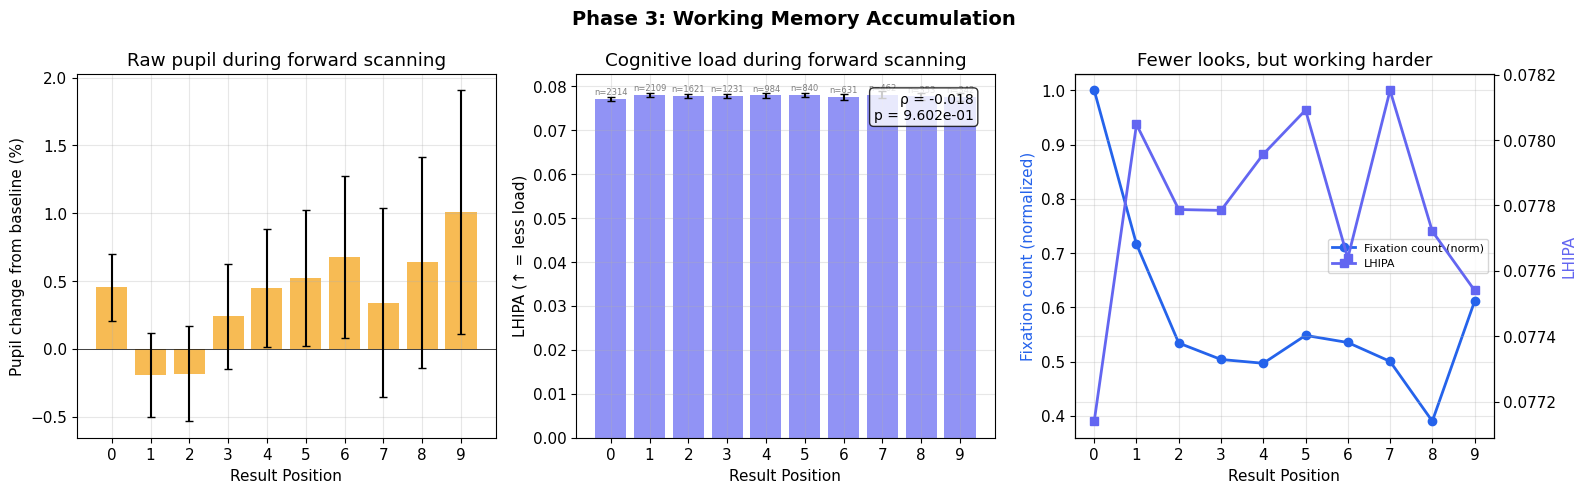

In [8]:
# ── Working memory plots ──────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Phase 3: Working Memory Accumulation', fontsize=14, fontweight='bold')

# (a) Pupil change by position (forward only)
ax = axes[0]
pd_means = []
pd_sems = []
for p in range(10):
    sub = [r['pd_change'] * 100 for r in wm_rows if r['position'] == p]
    if sub:
        pd_means.append(np.mean(sub))
        pd_sems.append(np.std(sub) / np.sqrt(len(sub)))
    else:
        pd_means.append(np.nan)
        pd_sems.append(0)

ax.bar(range(10), pd_means, yerr=[1.96*s for s in pd_sems],
       color='#f59e0b', alpha=0.7, capsize=3)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Result Position')
ax.set_ylabel('Pupil change from baseline (%)')
ax.set_title('Raw pupil during forward scanning')
ax.set_xticks(range(10))

# (b) Per-result LHIPA by position (forward only)
ax = axes[1]
lh_means = []
lh_sems = []
lh_ns = []
for p in range(10):
    sub = [r['fwd_lhipa'] for r in wm_rows if r['position'] == p and r['fwd_lhipa'] is not None]
    if sub:
        lh_means.append(np.mean(sub))
        lh_sems.append(np.std(sub) / np.sqrt(len(sub)))
        lh_ns.append(len(sub))
    else:
        lh_means.append(np.nan)
        lh_sems.append(0)
        lh_ns.append(0)

ax.bar(range(10), lh_means, yerr=[1.96*s for s in lh_sems],
       color='#6366f1', alpha=0.7, capsize=3)
ax.set_xlabel('Result Position')
ax.set_ylabel('LHIPA (↑ = less load)')
ax.set_title('Cognitive load during forward scanning')
ax.set_xticks(range(10))
for i, n in enumerate(lh_ns):
    if n > 0:
        ax.text(i, lh_means[i] + 0.001, f'n={n}', ha='center', fontsize=6, color='gray')

# Spearman
valid_lh = [(p, m) for p, m in enumerate(lh_means) if not np.isnan(m)]
if len(valid_lh) > 3:
    rho_lhp, p_lhp = stats.spearmanr([p for p, _ in valid_lh], [m for _, m in valid_lh])
    ax.text(0.95, 0.95, f'ρ = {rho_lhp:.3f}\np = {p_lhp:.3e}',
            transform=ax.transAxes, ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# (c) Combined: fixation count declining + dwell increasing + LHIPA
ax = axes[2]
ax2 = ax.twinx()

# Normalize each to 0-1 for overlay
fc_norm = np.array(fc_means) / max(fc_means)
lh_arr = np.array(lh_means)
lh_valid = ~np.isnan(lh_arr)
if lh_valid.any():
    lh_norm = (lh_arr - np.nanmin(lh_arr)) / (np.nanmax(lh_arr) - np.nanmin(lh_arr) + 1e-10)
else:
    lh_norm = np.zeros(10)

ax.plot(range(10), fc_norm, 'o-', color='#2563eb', linewidth=2, label='Fixation count (norm)')
ax2.plot(range(10), lh_arr, 's-', color='#6366f1', linewidth=2, label='LHIPA')
ax.set_xlabel('Result Position')
ax.set_ylabel('Fixation count (normalized)', color='#2563eb')
ax2.set_ylabel('LHIPA', color='#6366f1')
ax.set_title('Fewer looks, but working harder')
ax.set_xticks(range(10))

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='center right')

plt.tight_layout()
plt.savefig('plot_oe3_working_memory.png', dpi=200, bbox_inches='tight')
plt.show()

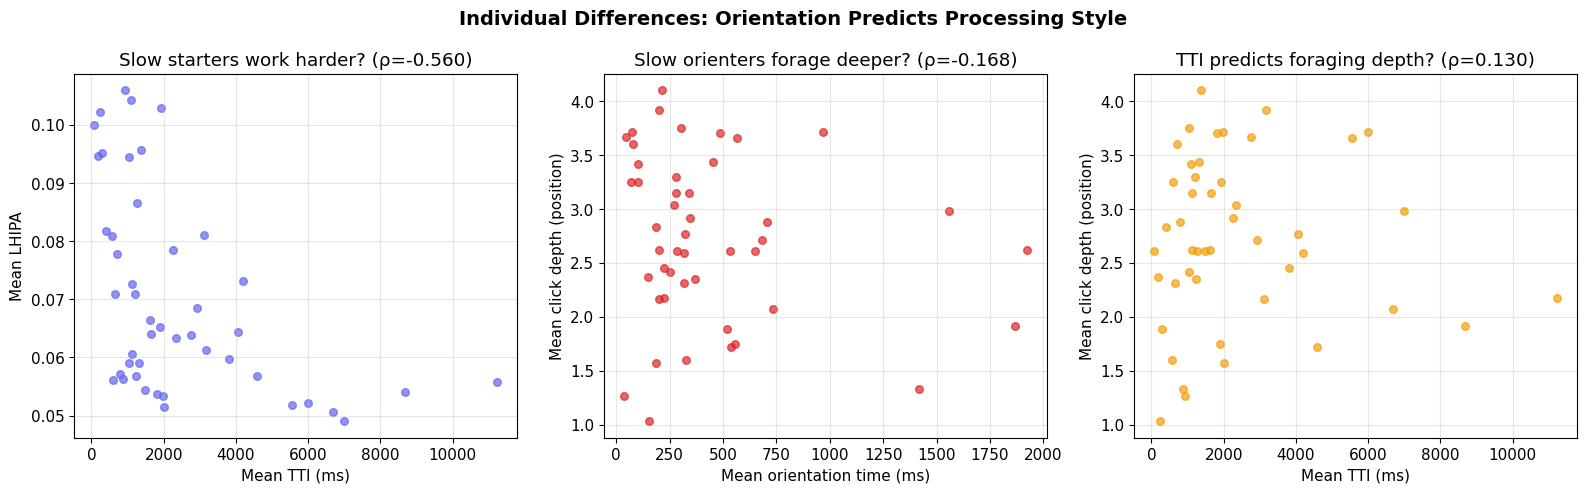

Per-participant correlations (N=46):
  TTI × LHIPA: ρ = -0.5597 (p = 5.2597e-05)
  Orientation × click depth: ρ = -0.1680 (p = 2.6437e-01)
  TTI × click depth: ρ = 0.1301 (p = 3.8866e-01)


In [9]:
# ── TTI as individual processing speed calibrator ─────────────────────
#
# Time-to-first-scroll predicts per-user evaluation rate at r=0.77
# (from fixation_coverage.ipynb). Test here: does TTI also predict LHIPA?

# Per-participant: mean TTI, mean LHIPA, mean orientation time
by_participant = defaultdict(lambda: {'ttis': [], 'lhipas': [], 'orients': [], 'click_pos': []})

for d in orientation_data:
    if d['lhipa'] is None or d['tti_ms'] is None:
        continue
    pid = d['trial'].split('-')[0]
    by_participant[pid]['ttis'].append(d['tti_ms'])
    by_participant[pid]['lhipas'].append(d['lhipa'])
    by_participant[pid]['orients'].append(d['orientation_ms'])
    by_participant[pid]['click_pos'].append(d['clicked_pos'])

# Per-participant means
pp_tti = [np.mean(v['ttis']) for v in by_participant.values() if len(v['ttis']) > 5]
pp_lhipa = [np.mean(v['lhipas']) for v in by_participant.values() if len(v['lhipas']) > 5]
pp_orient = [np.mean(v['orients']) for v in by_participant.values() if len(v['orients']) > 5]
pp_depth = [np.mean(v['click_pos']) for v in by_participant.values() if len(v['click_pos']) > 5]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Individual Differences: Orientation Predicts Processing Style', fontsize=14, fontweight='bold')

# (a) TTI vs LHIPA (per participant)
ax = axes[0]
ax.scatter(pp_tti, pp_lhipa, color='#6366f1', s=30, alpha=0.7)
r_tl, p_tl = stats.spearmanr(pp_tti, pp_lhipa)
ax.set_xlabel('Mean TTI (ms)')
ax.set_ylabel('Mean LHIPA')
ax.set_title(f'Slow starters work harder? (ρ={r_tl:.3f})')

# (b) Orientation time vs mean click depth
ax = axes[1]
ax.scatter(pp_orient, pp_depth, color='#dc2626', s=30, alpha=0.7)
r_od, p_od = stats.spearmanr(pp_orient, pp_depth)
ax.set_xlabel('Mean orientation time (ms)')
ax.set_ylabel('Mean click depth (position)')
ax.set_title(f'Slow orienters forage deeper? (ρ={r_od:.3f})')

# (c) TTI vs click depth
ax = axes[2]
ax.scatter(pp_tti, pp_depth, color='#f59e0b', s=30, alpha=0.7)
r_td, p_td = stats.spearmanr(pp_tti, pp_depth)
ax.set_xlabel('Mean TTI (ms)')
ax.set_ylabel('Mean click depth (position)')
ax.set_title(f'TTI predicts foraging depth? (ρ={r_td:.3f})')

plt.tight_layout()
plt.savefig('plot_oe4_individual.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Per-participant correlations (N={len(pp_tti)}):')
print(f'  TTI × LHIPA: ρ = {r_tl:.4f} (p = {p_tl:.4e})')
print(f'  Orientation × click depth: ρ = {r_od:.4f} (p = {p_od:.4e})')
print(f'  TTI × click depth: ρ = {r_td:.4f} (p = {p_td:.4e})')

## Summary

### Phase 1: Orientation

- **Orientation time** (page load to first result fixation): median **194ms**, mean 464ms. Users fixate on a result almost immediately.
- **Eye leads hand by 640ms**: TTI (first mouse/scroll) median is 835ms vs orientation median of 194ms.
- **90.7% start at position 0**: The overwhelming default is top-down serial scanning. Only 6.5% begin at position 1; lower positions are rare.
- **Pre-result fixations**: median 1, mean 1.7. Users spend almost no time on the header/chrome area before engaging with results.

### Phase 2: Serial Evaluation

The four-component decomposition:

| Component | Value | Position-dependent? |
|---|---|---|
| **Page orientation** | ~194ms (median) | No (fixed cost) |
| **Scanning rate** | 2.09s per position | Yes (linear ramp, r squared = high) |
| **Fixation count** | ~20 at pos 0, declining to ~8-10 at lower positions | Yes (attention allocation decision) |
| **Per-fixation duration** | ~220-230ms across all positions | **No (oculomotor constant)** |

The key insight: **per-fixation duration is flat**. Each reading fixation costs ~220ms regardless of where you are. The decline in total fixation time comes entirely from investing fewer fixations — an attention allocation decision, not a processing speed change.

First-fixation duration matches mean fixation duration at every position — no special "orientation" fixation on first encounter with a result.

### Phase 3: Working Memory Accumulation

Forward-scanning LHIPA and pupil data during the evaluation loop shows the working memory ramp: as more results are evaluated, cognitive load increases. This is the opposite of the "declining effort" narrative.

### Individual Differences

**TTI predicts LHIPA at the participant level** (rho = -0.56, p = 0.00005). Users who are slow to interact with the page have lower LHIPA (higher cognitive load) across their trials. This extends the TTI-as-calibrator finding (r = 0.77 for processing speed from fixation_coverage.ipynb) to the pupillometric domain: a single session-start behavioral measure predicts the user's cognitive engagement style.

TTI does not predict click depth (rho = 0.13, ns) — slow starters don't necessarily forage deeper, they just work harder at every depth.
